In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.metrics import Precision, Recall

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

2024-03-15 19:57:46.436776: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-15 19:57:46.436935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-15 19:57:46.562448: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_dir = "/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Train"
val_dir="/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Validation"
test_dir = "/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test"

resize_size = (240,240)

batch_size = 32

In [3]:
#train_data 
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size 
    )

#Classes Names
class_names= train_data.class_names
class_names

#labels are one-hot encoded

Found 1850 files belonging to 2 classes.


['Normal', 'Stroke']

In [18]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = val_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )


Found 347 files belonging to 2 classes.


In [4]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

# Define classes names
class_names = test_data.class_names
print("Class names:", class_names)

Found 117 files belonging to 2 classes.
Class names: ['Normal', 'Stroke']


In [5]:
def showSampleImages(data):
    class_names=data.class_names
    plt.figure(figsize=(12, 12))
    for images,labels in data.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])
            plt.axis("off")

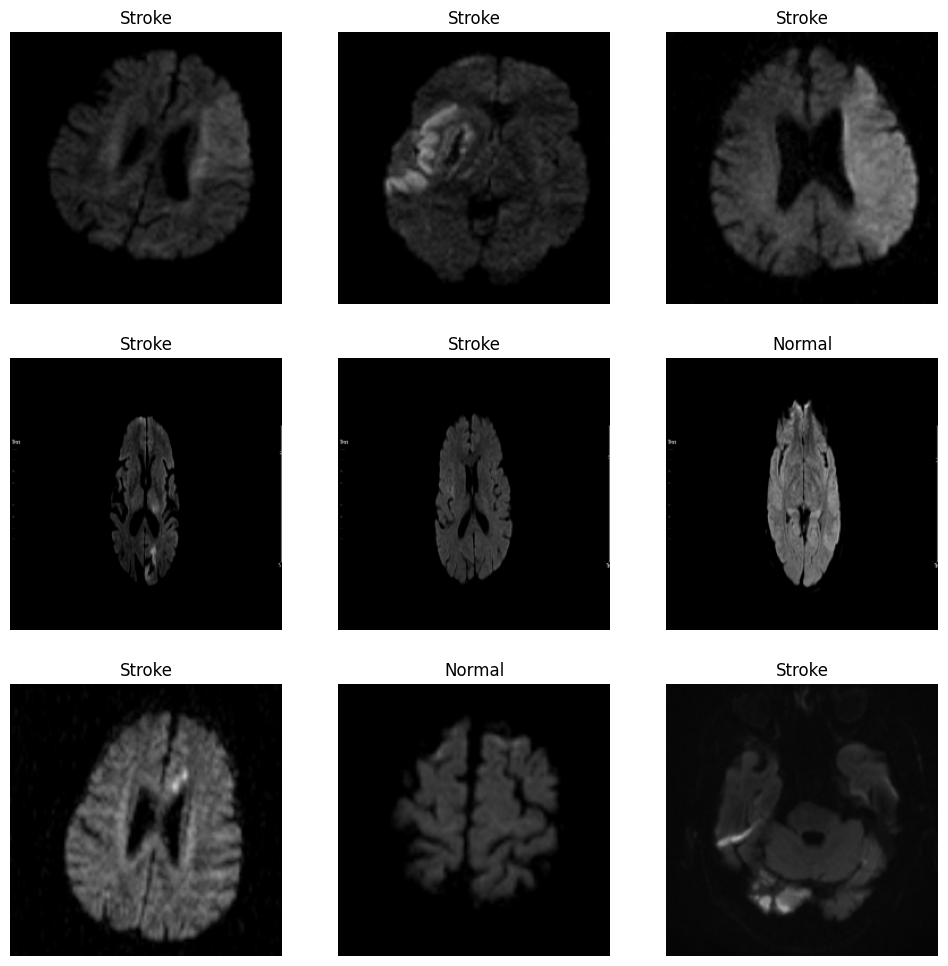

In [6]:
showSampleImages(train_data)


# Ckecking Count of data

In [7]:
def print_count_and_bar_graph(data,data_name,pallete_style="deep"):
    class_names=data.class_names
    ds=pd.DataFrame({'Class':class_names,'Count':len(class_names)*[0]})
    
    #Looping over the data
    for images,labels in data:
        for i in range(len(images)):
            for category in class_names:
                if class_names[tf.argmax(labels[i])]==category:
                    ds.loc[ds['Class']==category,'Count']+=1
    #print count
    for category in class_names:
        print(f"{category} : {ds.loc[ds['Class']==category,'Count']}")

    #print bar plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+data_name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()


Normal : 0    889
Name: Count, dtype: int64
Stroke : 1    961
Name: Count, dtype: int64


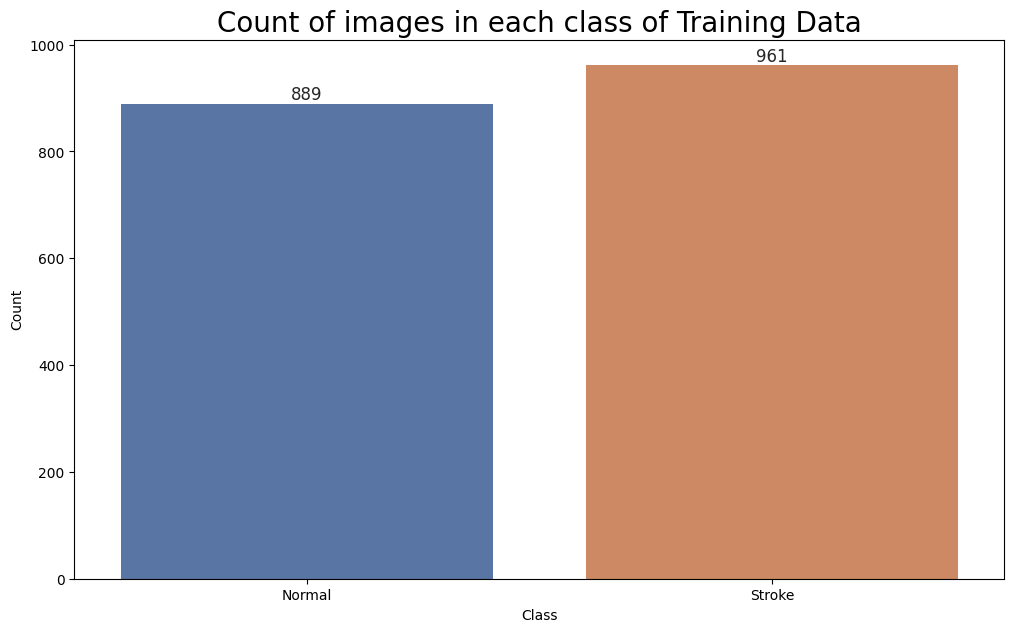

In [8]:
print_count_and_bar_graph(train_data,"Training Data")

Normal : 0    889
Name: Count, dtype: int64
Stroke : 1    961
Name: Count, dtype: int64


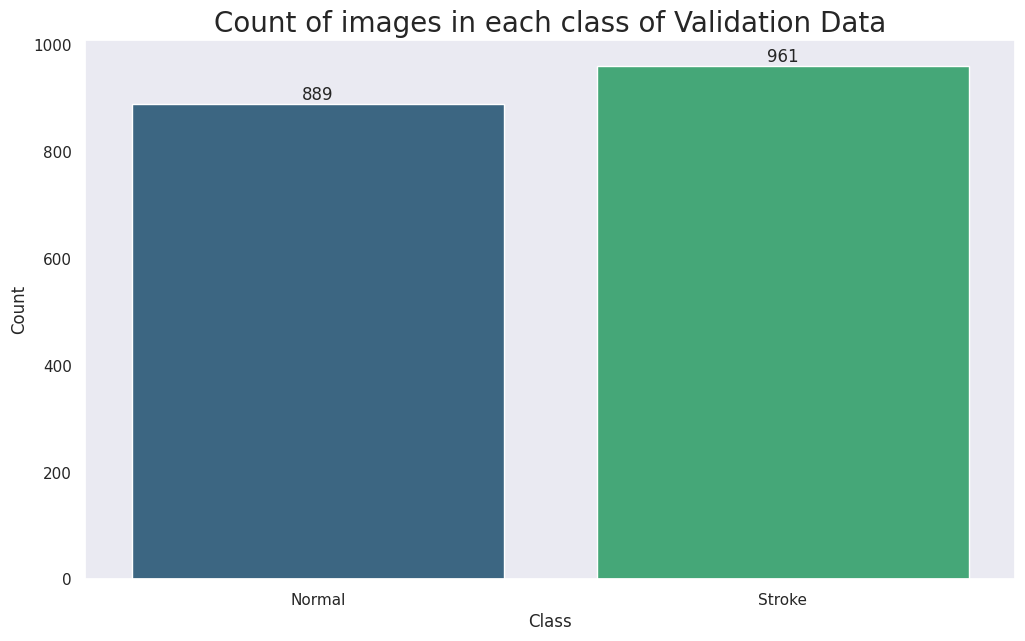

In [9]:
print_count_and_bar_graph(train_data,"Validation Data",pallete_style="viridis")

Normal : 0    56
Name: Count, dtype: int64
Stroke : 1    61
Name: Count, dtype: int64


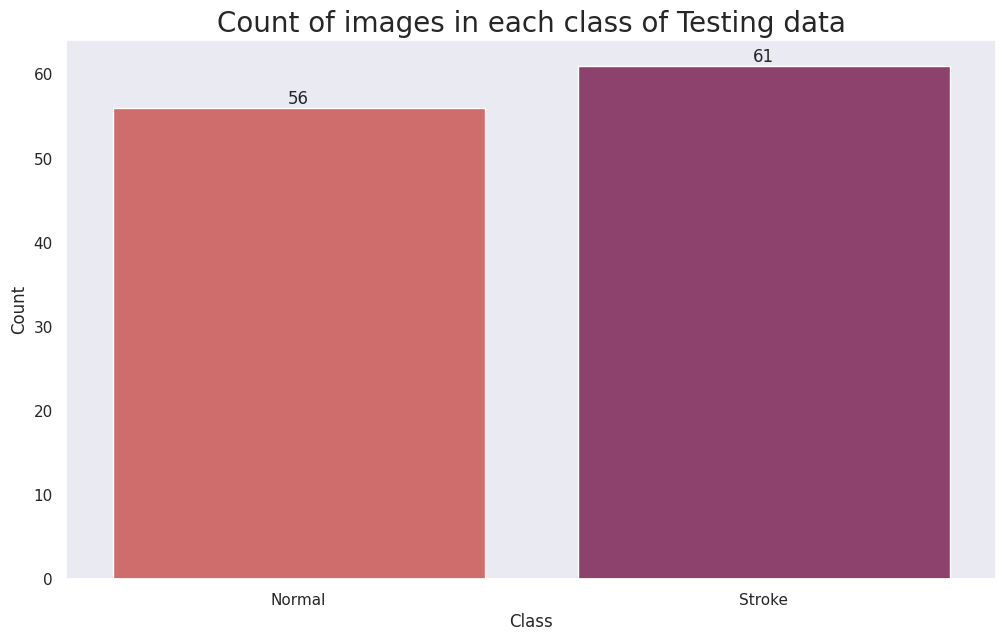

In [10]:
print_count_and_bar_graph(test_data,"Testing data",pallete_style="flare")

In [11]:
img_shape=(240,240,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.models import Model

In [14]:
x=base_model.output
x=Dropout(rate= 0.3)(x)
x=Dense(128, activation= 'relu')(x)
x=Dropout(rate= 0.25)(x)
x =Dense(2, activation="softmax")(x)

model = Model(base_model.input, x)


In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 119, 119,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 119, 119,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 119, 119,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 117, 117,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 117, 117,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 117, 117,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 117, 117,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 117, 117,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 117, 117,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 117, 117,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 117, 117,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 59, 59,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 59, 59,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 59,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 59, 59,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 59, 59,    │          0 │ add[0][0]       

 Total params: 21,124,010 (80.58 MB)

 Trainable params: 21,069,482 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [16]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=3,restore_best_weights=True),
    callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [20]:
 model.compile(loss = "categorical_crossentropy", 
                  optimizer = Adamax(learning_rate= 0.001),
                  metrics=['accuracy', Precision(), Recall()])
    

In [21]:
Model_History= model.fit(train_data,
                 epochs=10,
                 validation_data=val_data,
                 verbose = 1 ,
                 callbacks = callback_list,
                 shuffle= False)

Epoch 1/10


I0000 00:00:1710532971.937603     111 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1710532972.019480     111 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.7072 - loss: 0.6743 - precision: 0.7072 - recall: 0.7072

W0000 00:00:1710533031.066574     114 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


58/58 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7088 - loss: 0.6707 - precision: 0.7088 - recall: 0.7088 - val_accuracy: 0.8588 - val_loss: 0.4843 - val_precision: 0.8588 - val_recall: 0.8588 - learning_rate: 0.0010
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 324ms/step - accuracy: 0.9627 - loss: 0.1295 - precision: 0.9627 - recall: 0.9627 - val_accuracy: 0.9654 - val_loss: 0.1536 - val_precision: 0.9654 - val_recall: 0.9654 - learning_rate: 0.0010
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 322ms/step - accuracy: 0.9843 - loss: 0.0559 - precision: 0.9843 - recall: 0.9843 - val_accuracy: 0.9625 - val_loss: 0.1352 - val_precision: 0.9625 - val_recall: 0.9625 - learning_rate: 0.0010
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 324ms/step - accuracy: 0.9964 - loss: 0.0124 - precision: 0.9964 - recall: 0.9964 - val_accuracy: 0.9741 - val_loss: 0.0921 - val_precision: 0.9741 - val_recall: 0.9741 - learning_rate: 0.0010
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 320ms/step - accuracy: 0.9982 -

In [25]:
def plot_metrices_graphs(Model_History, start=0):
    metrices = {
        "train_Loss": Model_History.history['loss'],
        "val_Loss": Model_History.history['val_loss'],
        "train_Accuracy": Model_History.history['accuracy'],
        "val_Accuracy": Model_History.history['val_accuracy'],
        "train_Precision": Model_History.history['precision'],
        "val_Precision": Model_History.history['val_precision'],
        "train_Recall": Model_History.history['recall'],
        "val_Recall": Model_History.history['val_recall']
    }

    bestEpoch = {
        "Loss": np.argmin(metrices["val_Loss"]),
        "Accuracy": np.argmax(metrices["val_Accuracy"]),
        "Precision": np.argmax(metrices["val_Precision"]),
        "Recall": np.argmax(metrices["val_Recall"])
    }

    Epochs = [i + 1 for i in range(start, len(metrices['train_Accuracy']))]

    plt.figure(figsize=(20, 12))
    plt.style.use('fivethirtyeight')

    i = 0
    for j in range(0, 4):
        plt.subplot(2, 2, j+1)
        plt.plot(Epochs, metrices["train_" + list(bestEpoch.keys())[j]], 'r', label=f'Training {list(bestEpoch.keys())[j]}')
        plt.plot(Epochs, metrices["val_" + list(bestEpoch.keys())[j]], 'g', label=f'Validation {list(bestEpoch.keys())[j]}')
        plt.scatter(bestEpoch[list(bestEpoch.keys())[j]], metrices["val_" + list(bestEpoch.keys())[j]][bestEpoch[list(bestEpoch.keys())[j]]], s=150, c='blue', label=f'Best Epoch = {bestEpoch[list(bestEpoch.keys())[j]]}')
        plt.title(f'Training and Validation {list(bestEpoch.keys())[j]}')
        plt.xlabel('Epochs')
        plt.ylabel(f'{list(bestEpoch.keys())[j]}')
        plt.legend()
        plt.grid(True)
        i += 1

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()


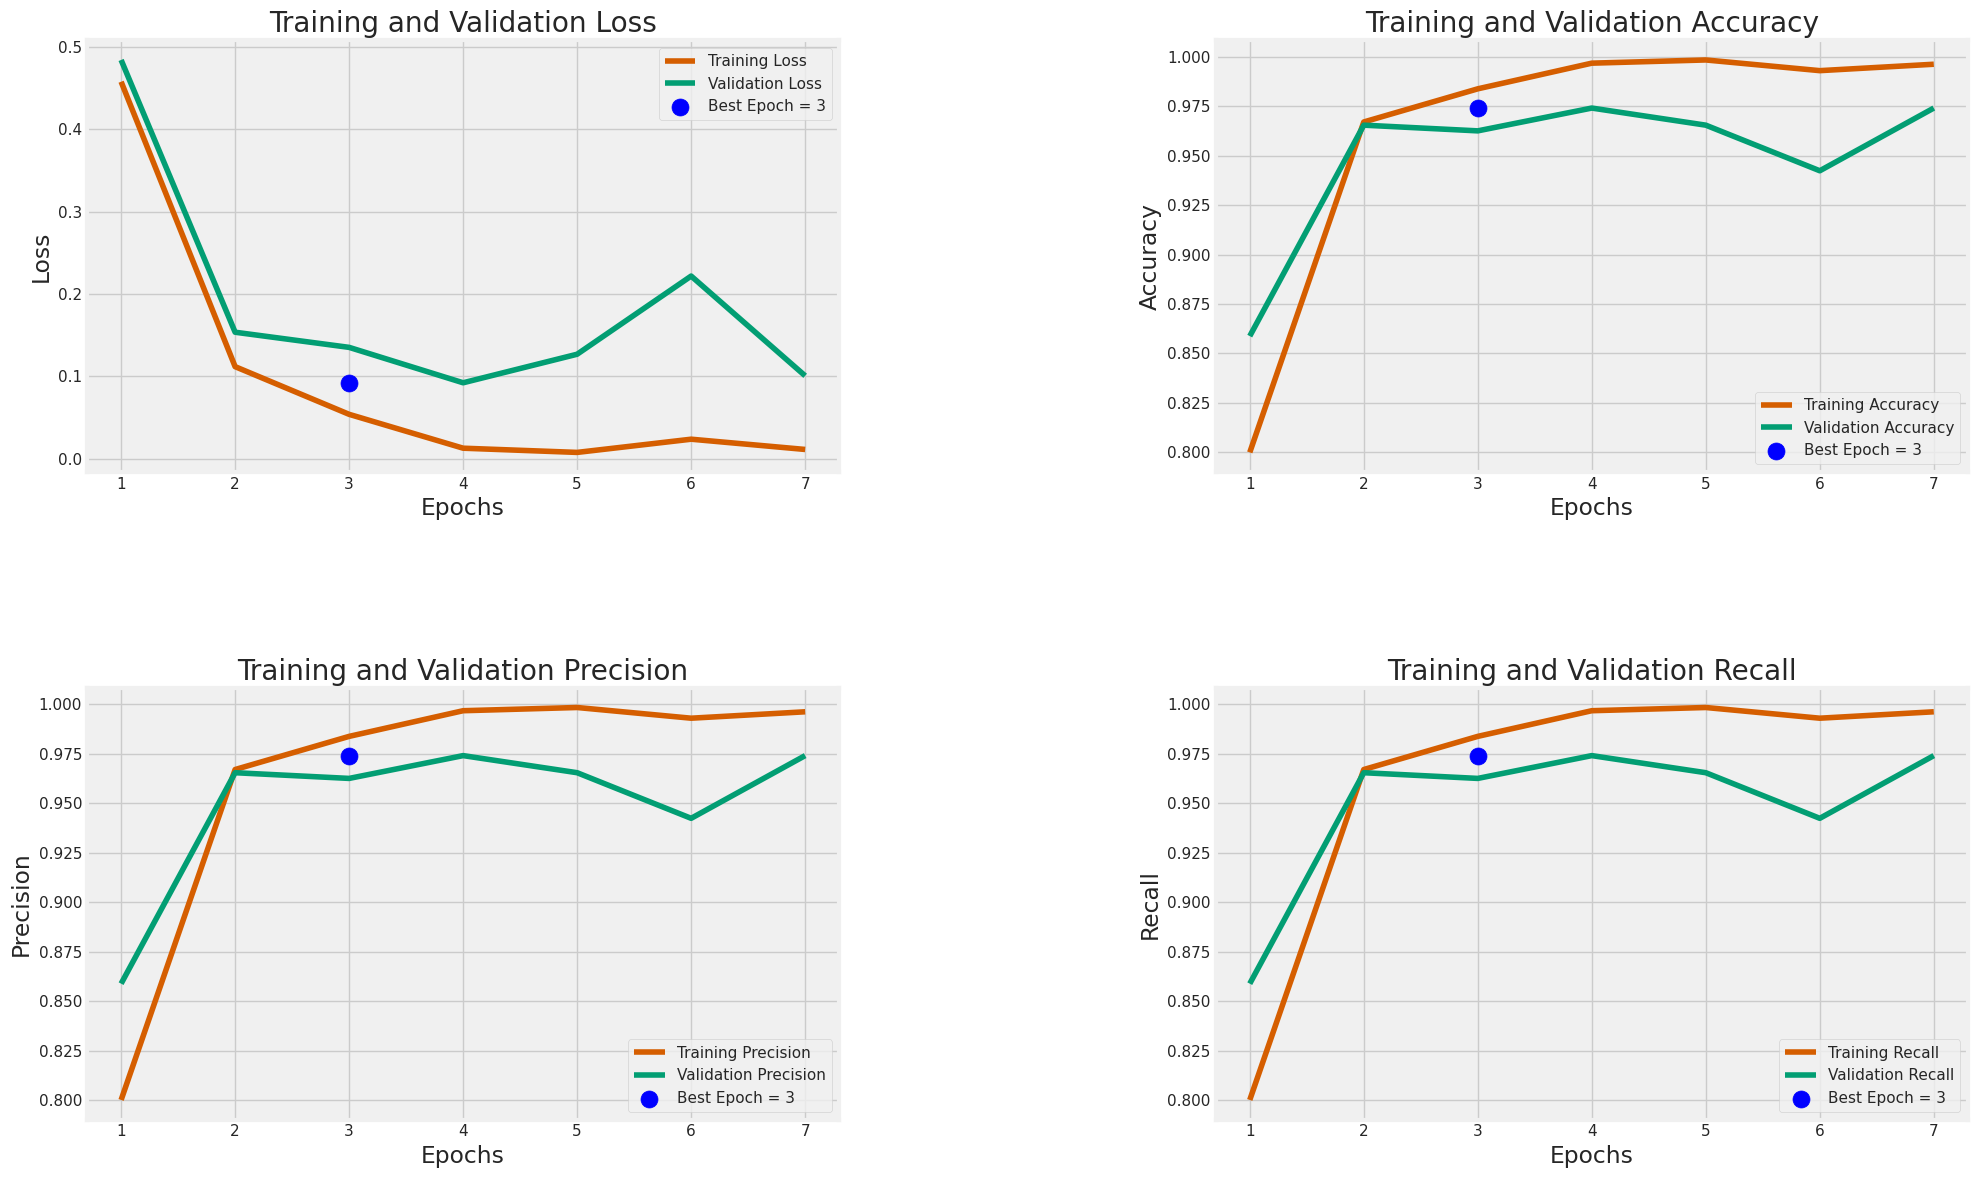

In [26]:
plot_metrices_graphs(Model_History)

In [27]:
def Evaluate_Model(model,train_data,test_data):
    train_score = model.evaluate(train_data, verbose=1)
    test_score = model.evaluate(test_data,verbose=1)

    print(f"Train Loss: {train_score[0]:.4f}")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print('-' * 30)
    print(f"Test Loss: {test_score[0]:.4f}")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

In [28]:
Evaluate_Model(model,train_data,test_data)

58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.9997 - loss: 0.0021 - precision: 0.9997 - recall: 0.9997
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9827 - loss: 0.1004 - precision: 0.9827 - recall: 0.9827
Train Loss: 0.0033
Train Accuracy: 99.95%
------------------------------
Test Loss: 0.0904
Test Accuracy: 98.29%


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

def printClassificationReportAndConfusionMaxtrix(model, class_names, data):
    true_labels = []
    predicted_labels = []

    for images, labels in data:
        true_labels.extend(np.argmax(labels.numpy(),axis=1))  # Convert one-hot encoded labels to class indices
        predicted_labels.extend(np.argmax(model.predict(images),axis=1))  # Obtain model predictions

    # Print classification report
    print("\n" * 5)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    print("\n" * 5)

    # Compute the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


W0000 00:00:1710533260.378545     112 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step






              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98        56
      Stroke       1.00      0.97      0.98        61

    accuracy                           0.98       117
   macro avg       0.98      0.98      0.98       117
weighted avg       0.98      0.98      0.98       117









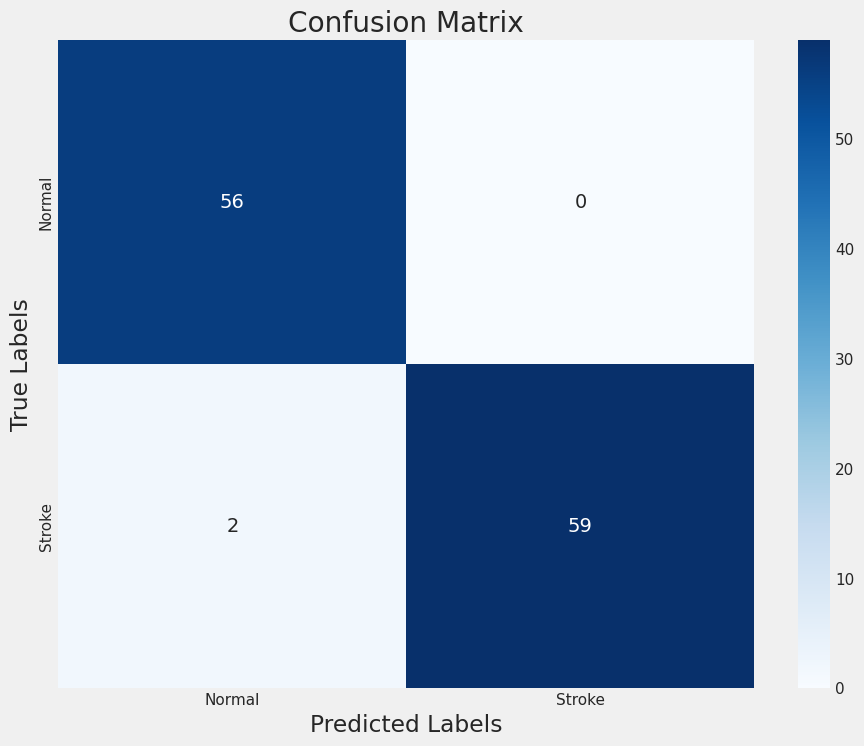

In [30]:
printClassificationReportAndConfusionMaxtrix(model,class_names,test_data)

In [40]:
model.save("stroke_xception.h5")

In [32]:
import cv2
from PIL import Image
import scipy  #Used to upsample our image
from matplotlib.patches import Rectangle #To add a rectangle overlay to the image
from skimage.feature.peak import peak_local_max  #To detect hotspots in 2D images. 

In [33]:
def getImage(img_path):
    image = cv2.imread(img_path)
    image = Image.fromarray(image, 'RGB')
    image = image.resize(resize_size)
    image = np.array(image)
    return image

In [34]:
def showPredictionStatistics(img_path,class_names=class_names,size=resize_size):
    plt.figure(figsize=(6, 6))
    img=getImage(img_path)
    predictions = model.predict(np.expand_dims(img, axis=0))
    probs = list(predictions[0]*100)
    print(probs)
    labels = class_names
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Percentage', fontsize=20)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[99.90674, 0.093261205]


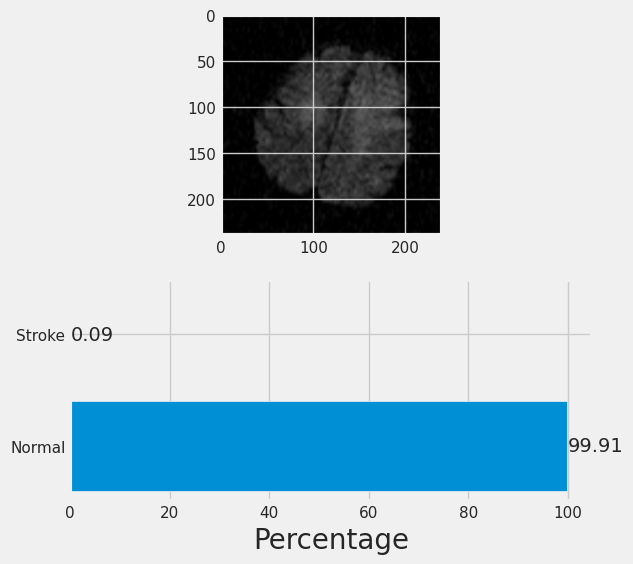

In [35]:
showPredictionStatistics('/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test/Normal/1 (287).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[91.77945, 8.220544]


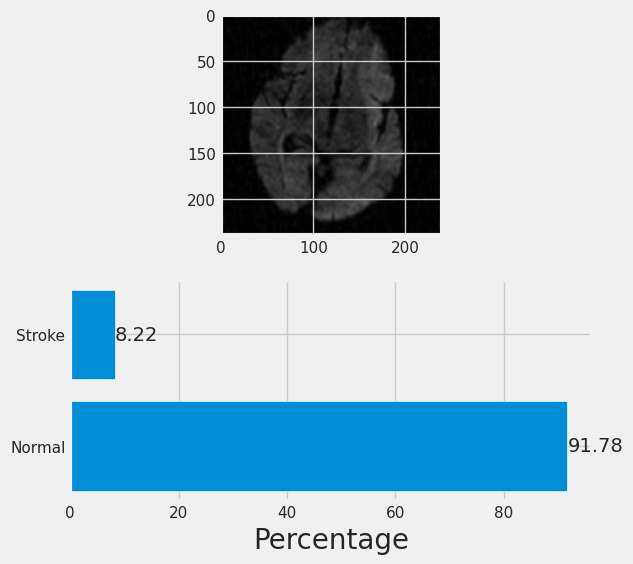

In [36]:
showPredictionStatistics('/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test/Stroke/2 (169).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[1.2057359e-05, 99.999985]


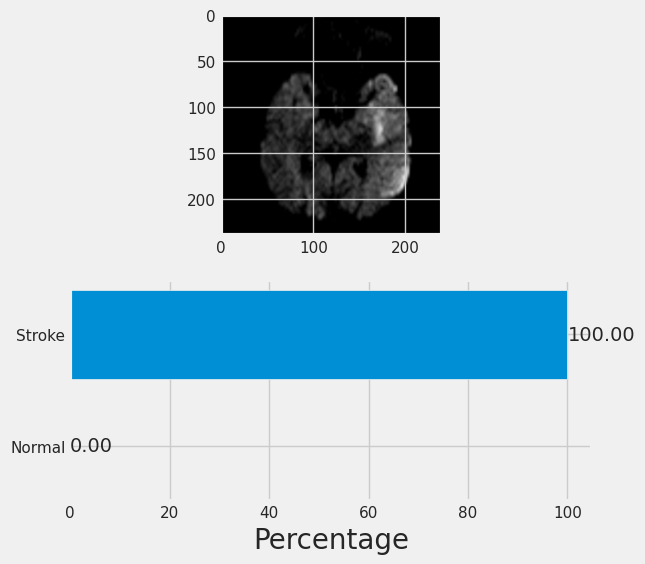

In [37]:
showPredictionStatistics('/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test/Stroke/2 (418).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.0026557625, 99.997345]


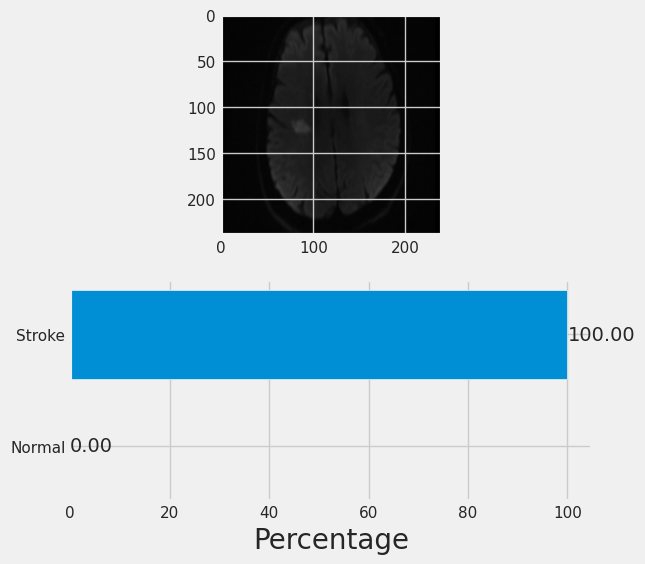

In [38]:
showPredictionStatistics('/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test/Stroke/2 (871).png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[99.999344, 0.0006544587]


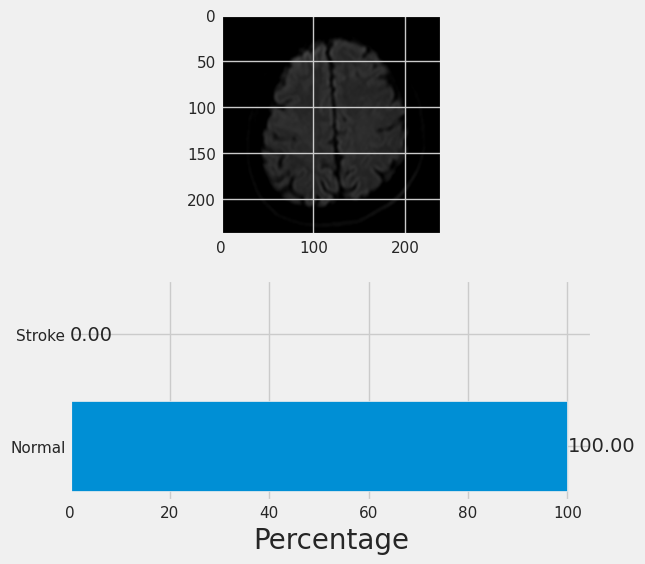

In [39]:
showPredictionStatistics('/kaggle/input/brain-stroke-ct-scan-image/Brain_Stroke_CT-SCAN_image/Test/Normal/1 (498).png')